In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

/glade/work/aasche/conda-envs/aires/lib/python3.11/zoneinfo/_tzpath.py:44: InvalidTZPathWarning: Invalid paths specified in PYTHONTZPATH environment variable. Paths should be absolute but found the following relative paths:
    None/share/zoneinfo
    None/share/tzinfo
  warnings.warn(


In [2]:
import sys
sys.path.append('/glade/u/home/aasche/PanguWeather/v2.0/')
from plot_config import params, contourLevels, colormap, savefig_format, SAVE_DIR
plt.rcParams.update(params)

#### Paper figure

In [5]:
def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')

var_configs = {
    'tas': {'name': 'T$_{2m}$', 'level': None},
    'zg':  {'name': 'Z$_{500}$', 'level': 50000}
}

methods = ['single', 'mean', 'persistence', 'climatology']

forecast_styles = {
    'single': {'color': 'goldenrod', 'label': 'Single Member'},
    'mean': {'color': 'red', 'label': 'Ensemble Mean'},
    'persistence': {'color': 'blue', 'label': 'Persistence'},
    'climatology': {'color': 'black', 'label': 'Climatology'}
}

# Load deterministic datasets
det_datasets = {
    method: xr.open_dataset(
        f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc"
        if method != "climatology"
        else "/glade/derecho/scratch/aasche/PLASIM/results/paper/climatology_global_mean_MSE_tas_zg.nc"
    )
    for method in methods
}

# Best offset per metric (12h, 18h, 6h)
best_offsets = {
    "tas_persistence": np.timedelta64(int(0.25 * 24 * 60 * 60), 's'),
    "tas_forecast": np.timedelta64(int(0 * 24 * 60 * 60), 's'),
    "hus_forecast": np.timedelta64(int(0.5 * 24 * 60 * 60), 's'),
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

/glade/derecho/scratch/aasche/tmp/ipykernel_68016/2746306566.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(
/glade/derecho/scratch/aasche/tmp/ipykernel_68016/2746306566.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(
/glade/derecho/scratch/aasche/tmp/ipykernel_68016/2746306566.py:20: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(
/glade/derecho/scratch/aasche/tmp/ipykernel_68016/2746306566.py:20: FutureWarning: In a future version of xarray decode_t

/glade/derecho/scratch/aasche/tmp/ipykernel_68016/3192697540.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


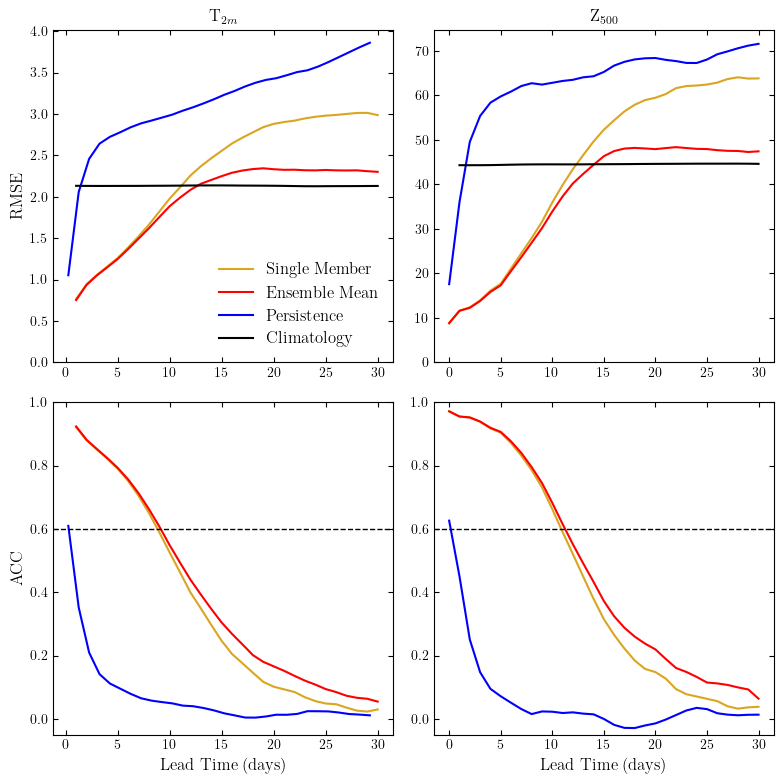

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8), layout="compressed")
fig.patch.set_facecolor("w")

# Map metrics and vars to subplot locations (RMSE top row, ACC bottom row)
plot_order = [
    ("RMSE", "tas"),
    ("RMSE", "zg"),
    ("ACC", "tas"),
    ("ACC", "zg"),
]

for idx, (ax, (metric, var)) in enumerate(zip(axes.flat, plot_order)):
    cfg = var_configs[var]

    for method in methods:
        # skip climatology for ACC
        if (metric == "ACC") and (method == "climatology"):
            continue

        ds = det_datasets[method]

        # Select lead times depending on method/variable
        if (var == "tas") and (method == "persistence"):
            offset = best_offsets["tas_persistence"]
            data = select_leads_by_offset(ds[var], offset)
            lead_days = lead_time_days(data)
        elif var == "tas":
            offset = best_offsets["tas_forecast"]
            data = select_leads_by_offset(ds[var], offset)
            lead_days = lead_time_days(data)
        else:
            data = ds[var]
            lead_days = pd.to_timedelta(ds["lead_time"].values) / np.timedelta64(1, "D")

        # Choose metric key depending on method/metric
        if metric == "RMSE":
            metric_key = "EnsembleMeanMSE" if method == "climatology" else "MSE"
        else:
            metric_key = "ACC"

        # Extract metric data
        if cfg["level"] is None:
            metric_data = data.sel(metric=metric_key).squeeze()
        else:
            metric_data = data.sel(metric=metric_key, level=cfg["level"]).squeeze()

        # RMSE requires square root
        if metric == "RMSE":
            metric_data = np.sqrt(metric_data)

        # --- Special handling for zg: collapse to daily best values ---
        if var == "zg":
            # convert lead_days to integer "day numbers"
            day_index = np.floor(lead_days).astype(int)

            if metric == "ACC":
                # best = max each day
                daily_best = [
                    metric_data[day_index == d].max().item()
                    for d in np.unique(day_index)
                ]
            else:  # RMSE
                # best = min each day
                daily_best = [
                    metric_data[day_index == d].min().item()
                    for d in np.unique(day_index)
                ]

            daily_days = np.unique(day_index)

            ax.plot(
                daily_days,
                daily_best,
                label=forecast_styles[method]["label"],
                color=forecast_styles[method]["color"],
            )

        else:
            # For tas, plot raw data
            ax.plot(
                lead_days,
                metric_data,
                label=forecast_styles[method]["label"],
                color=forecast_styles[method]["color"],
            )

    # Titles only for top row
    if idx // 2 == 0:
        ax.set_title(rf"{cfg['name']}")

    # Only bottom row gets xlabel
    if idx // 2 == 1:
        ax.set_xlabel(r"Lead Time (days)")

    # Only left column gets ylabel with metric
    if idx % 2 == 0:
        ax.set_ylabel(rf"{metric}")

    if metric == "ACC":
        ax.set_ylim(-0.05, 1)
        ax.axhline(0.6, color="k", linestyle="--", linewidth=1)
    else:
        ax.set_ylim(bottom=0)

# Legend inside bottom left subplot
handles, labels = axes[0,0].get_legend_handles_labels()
axes[0,0].legend(handles, labels, loc="best", frameon=False)

plt.tight_layout()
plt.savefig(SAVE_DIR + "four_panel_metrics." + savefig_format, dpi=600, bbox_inches="tight")
plt.show()

UPDATED

In [38]:
AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_updated.nc")
# A1 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_A1_updated.nc")
AT

/glade/derecho/scratch/aasche/tmp/ipykernel_127005/4246496781.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_updated.nc")


<xarray.Dataset> Size: 79kB
Dimensions:               (season: 1, region: 3, T: 3, prediction_timedelta: 109)
Coordinates:
  * season                (season) <U3 12B 'JJA'
  * region                (region) <U7 84B 'Chicago' 'France' 'PNW'
  * T                     (T) int64 24B 3 5 7
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 872B 06:00:0...
Data variables:
    rmse_single           (season, region, T, prediction_timedelta) float64 8kB ...
    corr_single           (season, region, T, prediction_timedelta) float64 8kB ...
    rmse_mean             (season, region, T, prediction_timedelta) float64 8kB ...
    corr_mean             (season, region, T, prediction_timedelta) float64 8kB ...
    rmse_clim             (season, region, T, prediction_timedelta) float64 8kB ...
    corr_clim             (season, region, T, prediction_timedelta) float64 8kB ...
    rmse_persist          (season, region, T, prediction_timedelta) float64 8kB ...
    corr_persist          (season, region, T, prediction_timedelta) float64 8kB ...
    crps_ens              (season, region, T, prediction_timedelta) float64 8kB ...
    crps_clim             (season, region, T, prediction_timedelta) float64 8kB ...

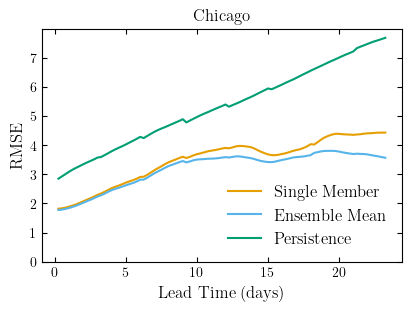

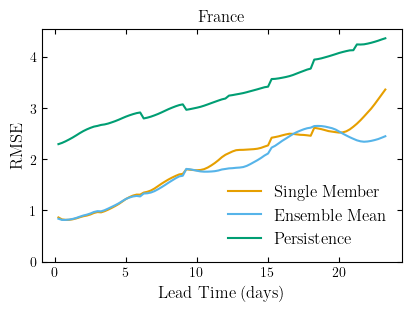

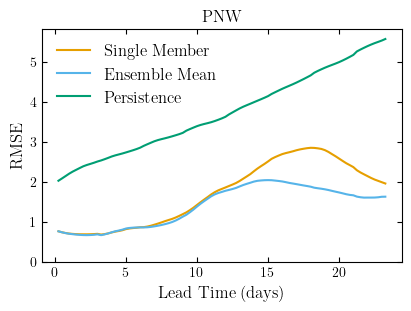

In [41]:
# Define a color-blind-friendly palette (e.g., Okabe-Ito)
forecast_styles = {
    'single': {'color': '#E69F00', 'label': 'Single Member'},    # orange
    'mean': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'persist': {'color': '#009E73', 'label': 'Persistence'}      # green
}

T_linestyles = {
    1: '-',
    3: '-',
    5: '-',
    7: '-'
}

# Use only JJA
ds_jja = AT.sel(season='JJA')
regions = ds_jja.region.values
Ts = [7]
timedays = ds_jja.prediction_timedelta / np.timedelta64(1, 'D')

for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'rmse_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays, data.values.squeeze(),
                    label=style['label'],
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )

        ax.set_title(region)
        ax.set_xlabel(r'Lead Time (days)')
        ax.set_ylabel(r'RMSE')
        ax.set_ylim(bottom=0)
        ax.legend(frameon=False)

    # plt.savefig(SAVE_DIR + f'rmse_{region}_{T}.' + savefig_format,
    #             dpi=600, format=savefig_format, bbox_inches='tight')
    plt.show()

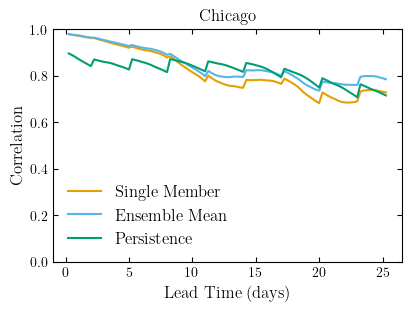

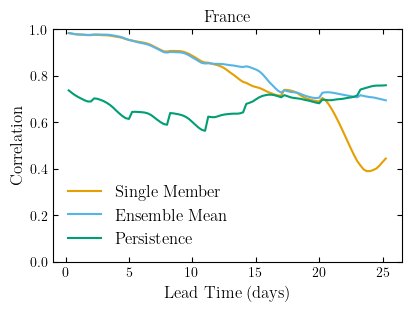

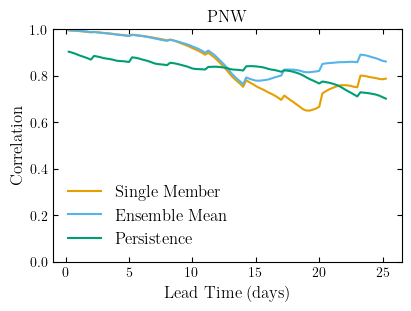

In [40]:
# Define a color-blind-friendly palette (e.g., Okabe-Ito)
forecast_styles = {
    'single': {'color': '#E69F00', 'label': 'Single Member'},    # orange
    'mean': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'persist': {'color': '#009E73', 'label': 'Persistence'}      # green
}
Ts = [5]
for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'corr_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays, data.values.squeeze(),
                    label=style['label'],
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )

        ax.set_title(region)
        ax.set_xlabel(r'Lead Time (days)')
        ax.set_ylabel(r'Correlation')
        ax.set_ylim(0, 1)
        ax.legend(frameon=False)

        # plt.savefig(SAVE_DIR + f'corr_{region}_{T}.' + savefig_format,
        #             dpi=600, format=savefig_format, bbox_inches='tight')
        plt.show()

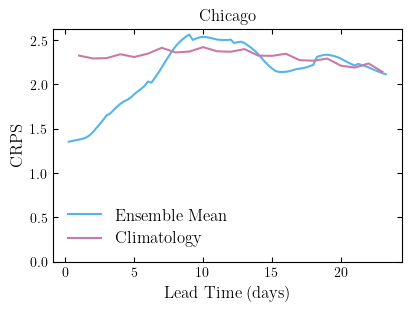

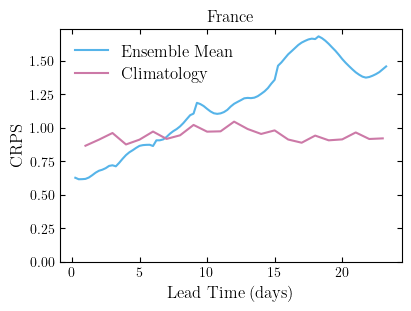

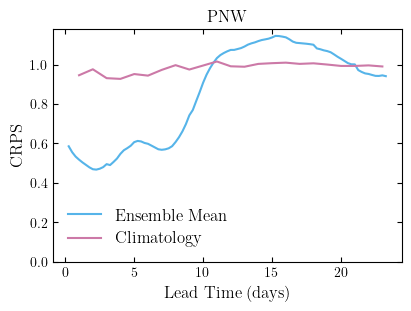

In [40]:
# Define a color-blind-friendly palette (e.g., Okabe-Ito)
forecast_styles = {
    'ens': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'clim': {'color': '#CC79A7', 'label': 'Climatology'}  # reddish-purple  
}

Ts = [7]

for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'crps_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                y = data.values.squeeze()

                if np.isnan(y).any():
                    # Overlay markers at valid points only
                    mask = ~np.isnan(y)
                    ax.plot(
                        timedays[mask], y[mask],
                        label=style['label'],
                        color=style['color'],
                        linestyle=T_linestyles[T]
                    )
                else:
                    ax.plot(
                        timedays, y,
                        label=style['label'],
                        color=style['color'],
                        linestyle=T_linestyles[T]
                    )

                

    ax.set_title(region)
    ax.set_xlabel(r'Lead Time (days)')
    ax.set_ylabel(r'CRPS')
    ax.set_ylim(0,)
    ax.legend(frameon=False)

    plt.show()

/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1096815215.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1096815215.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1096815215.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}


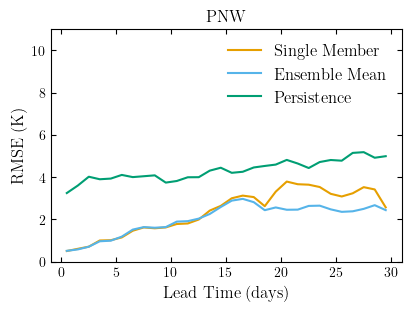

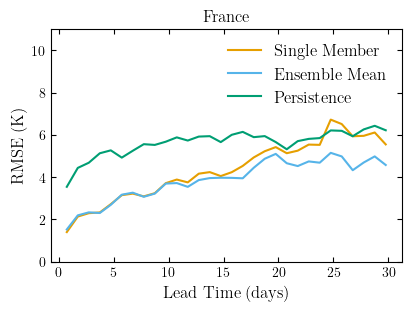

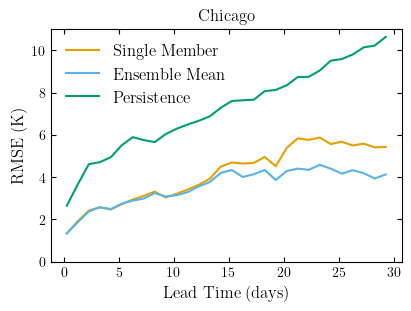

In [ ]:
methods = ['single', 'mean', 'persistence']
regions = ['PNW', 'France', 'Chicago']
var_name = 'tas'

# Colorblind-friendly color palette (same as used earlier)
forecast_styles = {
    'single': {'color': '#E69F00', 'label': 'Single Member'},    # orange
    'mean': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'persistence': {'color': '#009E73', 'label': 'Persistence'}  # green
}

# Load deterministic files
det_files = {m: f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{m}_JJA_tas_deterministic.nc" for m in methods}
det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}

# Best offset per region (12h, 18h, 6h)
best_offsets = {
    "PNW": np.timedelta64(int(0.5 * 24 * 60 * 60), 's'),
    "France": np.timedelta64(int(0.75 * 24 * 60 * 60), 's'),
    "Chicago": np.timedelta64(int(0.25 * 24 * 60 * 60), 's')
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')


for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')
    
    offset = best_offsets[region]

    for method in methods:
        ds_subset = select_leads_by_offset(det_ds[method], offset)
        mse = ds_subset[var_name].sel(metric='MSE', region=region)
        rmse = np.sqrt(mse)

        ax.plot(
            lead_time_days(ds_subset),
            rmse,
            label=forecast_styles[method]['label'],
            color=forecast_styles[method]['color']
        )

    ax.set_title(region)
    ax.set_xlabel('Lead Time (days)')
    ax.set_ylabel('RMSE (K)')
    ax.set_ylim(0, 11)
    ax.legend(frameon=False)

    plt.savefig(SAVE_DIR + f'rmse_JJA_{region}.' + savefig_format,
                dpi=600, format=savefig_format, bbox_inches='tight')
    plt.show()


/glade/derecho/scratch/aasche/tmp/ipykernel_2615/3246737658.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_2615/3246737658.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_2615/3246737658.py:14: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}


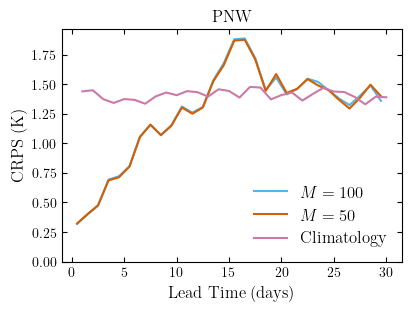

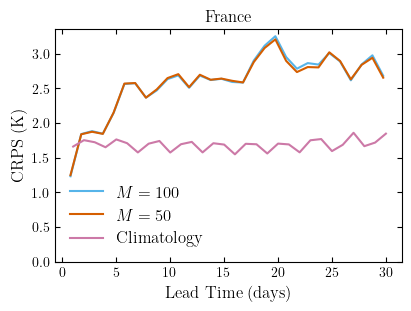

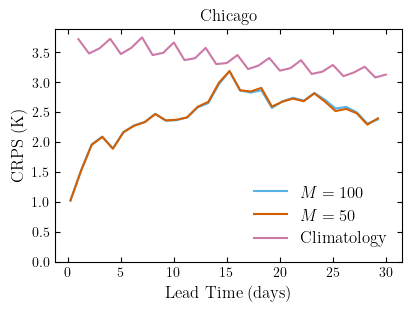

In [36]:
methods = ['ens100', 'ens_50', 'clim']
regions = ['PNW', 'France', 'Chicago']
var_name = 'tas'

# Colorblind-friendly color palette (same as used earlier)
forecast_styles = {
    'ens100': {'color': '#56B4E9', 'label': '$M=100$'},    # sky blue
    'ens_50': {'color': '#D55E00', 'label': '$M=50$'},      # vermillion (red-orange)
    'clim': {'color': '#CC79A7', 'label': 'Climatology'}  # reddish-purple     
}

# Load deterministic files
det_files = {m: f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{m}_CPRS_tas_JJA.nc" for m in methods}
det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}

# Best offset per region (12h, 18h, 6h)
best_offsets = {
    "PNW": np.timedelta64(int(0.5 * 24 * 60 * 60), 's'),
    "France": np.timedelta64(int(0.75 * 24 * 60 * 60), 's'),
    "Chicago": np.timedelta64(int(0.25 * 24 * 60 * 60), 's')
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')


for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')
    
    offset = best_offsets[region]

    for method in methods:
        if method == 'clim':
            ds_subset = det_ds[method]
        else:
            ds_subset = select_leads_by_offset(det_ds[method], offset)
        crps = ds_subset[var_name].sel(metric='CRPS', region=region)

        ax.plot(
            lead_time_days(ds_subset),
            crps,
            label=forecast_styles[method]['label'],
            color=forecast_styles[method]['color']
        )

    ax.set_title(region)
    ax.set_xlabel('Lead Time (days)')
    ax.set_ylabel('CRPS (K)')
    ax.set_ylim(bottom=0)
    # ax.set_ylim(0, 11)
    ax.legend(frameon=False)

    # plt.savefig(SAVE_DIR + f'rmse_JJA_{region}.' + savefig_format,
    #             dpi=600, format=savefig_format, bbox_inches='tight')
    plt.show()


/glade/derecho/scratch/aasche/tmp/ipykernel_2615/1641184357.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_2615/1641184357.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_2615/1641184357.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or 

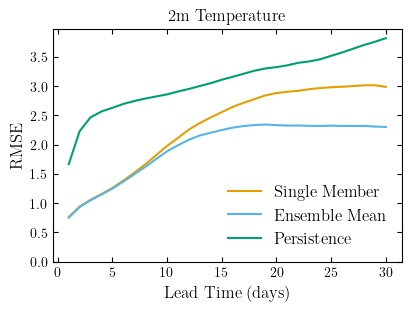

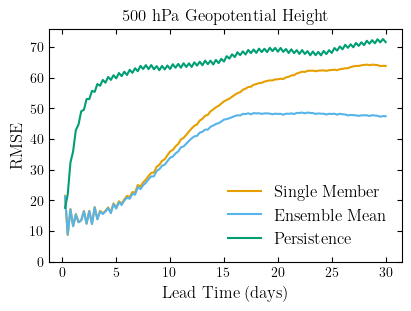

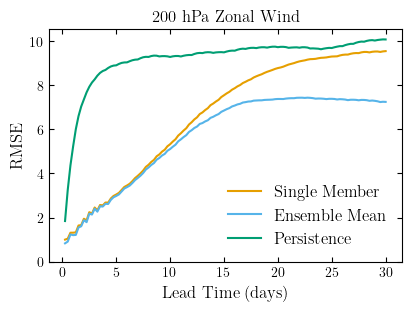

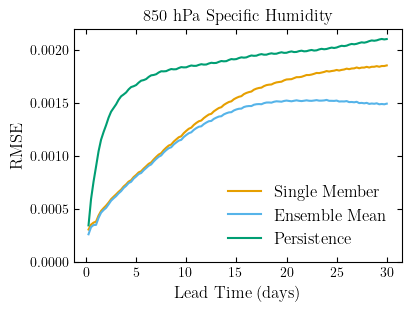

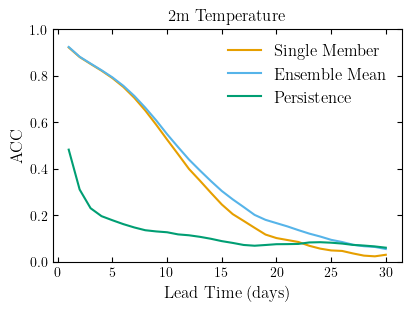

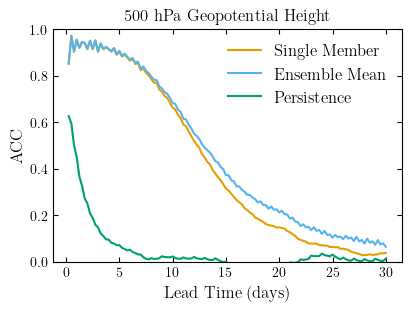

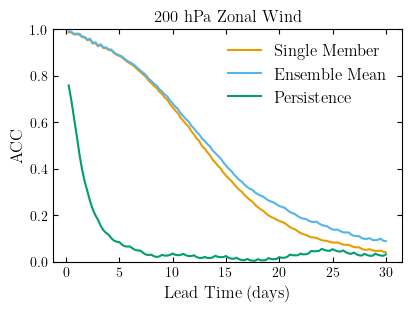

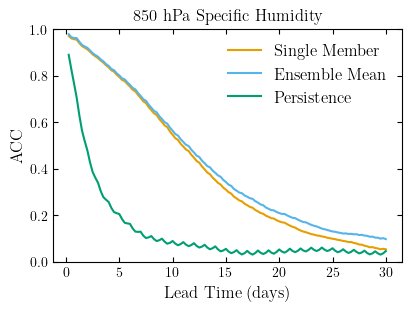

In [33]:
var_configs = {
    'tas': {'name': '2m Temperature', 'level': None},
    'zg':  {'name': '500 hPa Geopotential Height', 'level': 50000},
    'ua':  {'name': '200 hPa Zonal Wind', 'level': 20000},
    'hus': {'name': '850 hPa Specific Humidity', 'level': 85000}
}

methods = ['single', 'mean', 'persistence']

forecast_styles = {
    'single': {'color': '#E69F00', 'label': 'Single Member'},    # orange
    'mean': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'persistence': {'color': '#009E73', 'label': 'Persistence'}  # green
}

# Load deterministic datasets
det_datasets = {
    method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
    for method in methods
}

# Best offset per metric (12h, 18h, 6h)
best_offsets = {
    "tas_persistence": np.timedelta64(int(0.25 * 24 * 60 * 60), 's'),
    "tas_forecast": np.timedelta64(int(0 * 24 * 60 * 60), 's'),
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

for metric in ['RMSE', 'ACC']:
    for var, cfg in var_configs.items():
        fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
        fig.patch.set_facecolor('w')

        for method in methods:
            ds = det_datasets[method]

            if (var == 'tas') & (method == 'persistence'):
                offset = best_offsets['tas_persistence']
                data = select_leads_by_offset(ds[var], offset)
                lead_days = lead_time_days(data)
            if var == 'tas':
                offset = best_offsets['tas_forecast']
                data = select_leads_by_offset(ds[var], offset)
                lead_days = lead_time_days(data)
            else:
                data = ds[var]
                lead_days = pd.to_timedelta(ds['lead_time'].values) / np.timedelta64(1, 'D')

            if cfg['level'] is None:
                metric_data = data.sel(metric='MSE' if metric == 'RMSE' else 'ACC').squeeze()
            else:
                metric_data = data.sel(metric='MSE' if metric == 'RMSE' else 'ACC', level=cfg['level']).squeeze()

            if metric == 'RMSE':
                metric_data = np.sqrt(metric_data)

            ax.plot(
                lead_days,
                metric_data,
                label=forecast_styles[method]['label'],
                color=forecast_styles[method]['color']
            )

        ax.set_title(rf"{cfg['name']}")
        ax.set_xlabel(r"Lead Time (days)")
        ax.set_ylabel(rf"{metric}")
        ax.set_ylim((0, 1) if metric == 'ACC' else (0, None))
        if metric == 'ACC':
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(bottom=0)

        # # Legend only on last plot per metric (optional: only for one figure)
        # if var == list(var_configs.keys())[-1]:
        ax.legend(frameon=False)

        plt.savefig(
            SAVE_DIR + f"{metric.lower()}_global_{var}." + savefig_format,
            dpi=600, bbox_inches='tight'
        )
        plt.show()


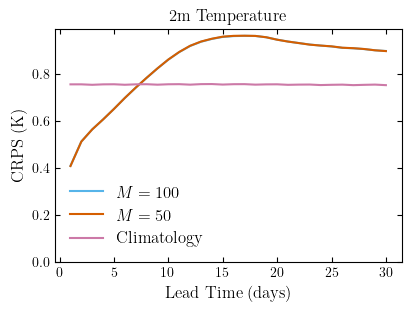

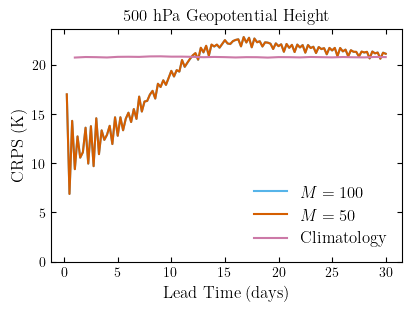

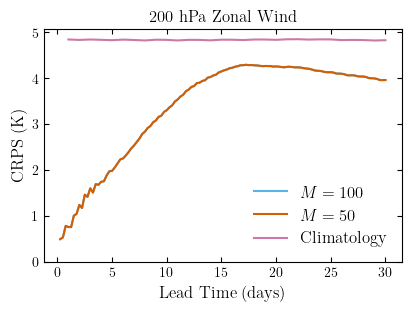

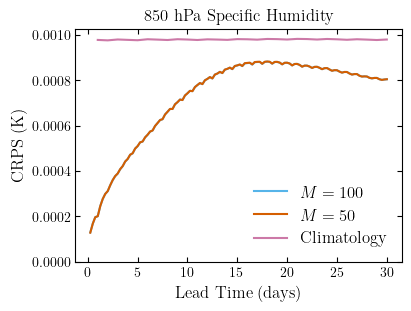

In [42]:
methods = ['ens100', 'ens50', 'clim']
var_configs = {
    'tas': {'name': '2m Temperature', 'level': None},
    'zg':  {'name': '500 hPa Geopotential Height', 'level': 50000},
    'ua':  {'name': '200 hPa Zonal Wind', 'level': 20000},
    'hus': {'name': '850 hPa Specific Humidity', 'level': 85000}
}

# Colorblind-friendly styles (most distinct)
forecast_styles = {
    'ens100': {'color': '#56B4E9', 'label': '$M=100$'},    # sky blue
    'ens50': {'color': '#D55E00', 'label': '$M=50$'},     # vermillion
    'clim':   {'color': '#CC79A7', 'label': 'Climatology'} # magenta
}

# ==== Helper functions ====
best_offsets = {
    "tas_crps": np.timedelta64(int(0 * 24 * 60 * 60), 's'),
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')

# ==== Load datasets ====
det_datasets = {}
for method in methods:
    method_files = {}
    for var in var_configs.keys():
        if method == 'ens100':
            filepath = f"/glade/derecho/scratch/aasche/PLASIM/results/paper/global_{var}_crps.nc"
        else:
            filepath = f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_{var}_crps.nc"
        method_files[var] = xr.open_dataset(filepath, decode_timedelta=True)
    det_datasets[method] = method_files

# ==== Plotting ====
for var, cfg in var_configs.items():
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for method in methods:
        ds = det_datasets[method][var]

        # Apply offsets for tas if needed
        if (var == 'tas') & ((method == 'ens100') | (method == 'ens50')):
            offset = best_offsets['tas_crps']
            data = select_leads_by_offset(ds[var], offset)
            lead_days = lead_time_days(data)
        else:
            data = ds[var]
            lead_days = pd.to_timedelta(ds['lead_time'].values) / np.timedelta64(1, 'D')

        lead_days = lead_time_days(data)

        # CRPS metric
        if cfg['level'] is None:
            metric_data = data.sel(metric='CRPS').squeeze()
        else:
            metric_data = data.sel(metric='CRPS', level=cfg['level']).squeeze()

        ax.plot(
            lead_days,
            metric_data,
            label=forecast_styles[method]['label'],
            color=forecast_styles[method]['color']
        )

    ax.set_title(cfg['name'])
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylabel("CRPS (K)")
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False)

    # plt.savefig(
    #     SAVE_DIR + f"crps_global_{var}." + savefig_format,
    #     dpi=600, bbox_inches='tight'
    # )
    plt.show()


In [33]:
brier = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/brier_99_ens100avg_unbiased.nc", decode_timedelta=True)
brier.coords['quantile'].values

array([0.99])

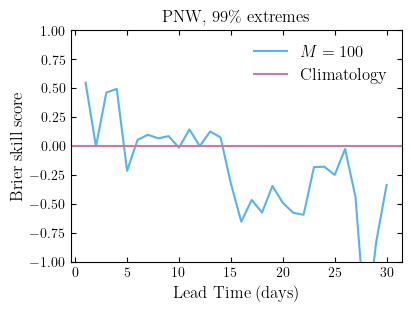

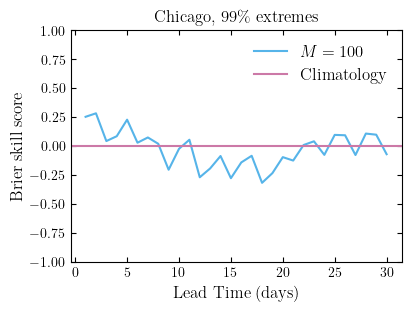

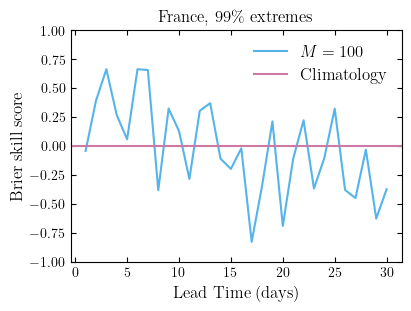

In [36]:
methods = ['ens100', 'clim']
var_configs = {
    'tas': {'name': '2m Temperature', 'level': None}
}

# Colorblind-friendly styles (most distinct)
forecast_styles = {
    'ens100': {'color': '#56B4E9', 'label': '$M=100$'},    # sky blue
    'clim':   {'color': '#CC79A7', 'label': 'Climatology'} # magenta
}

# ==== Helper functions ====
best_offsets = {
    "ens100": np.timedelta64(int(0.25 * 24 * 60 * 60), 's'),
    "clim": np.timedelta64(int(0 * 24 * 60 * 60), 's'),
}

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')

# ==== Function to compute Brier Skill Score ====
def compute_bss(forecast_ds, clim_ds, forecast_slice=slice(None), clim_slice=slice(None)):
    """
    Compute Brier Skill Score: BSS = 1 - Brier/Brier_clim
    """
    # Subset lead times
    # forecast_ds_sub = forecast_ds.isel(lead_time=forecast_slice)
    # clim_ds_sub = clim_ds.isel(lead_time=clim_slice)
    
    # # Align on lead_time
    # forecast_ds_aligned, clim_ds_aligned = xr.align(forecast_ds_sub, clim_ds_sub, join='inner')
    
    # Compute BSS
    bss = 1 - forecast_ds / clim_ds
    return bss

# ==== Load datasets ====
brier = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/brier_99_ens100avg_unbiased.nc", decode_timedelta=True)
brierclim = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/brier_99_clim_unbiased.nc", decode_timedelta=True)

quantiles = brier.coords['quantile'].values
for q in quantiles:
    for reg in ["PNW", "Chicago", "France"]:
        # Select specific quantile & first metric & region
        brier_q = brier.isel(metric=0).sel(region=reg,quantile=q)
        brierclim_q = brierclim.isel(metric=0).sel(region=reg,quantile=q)

        lead_days = lead_time_days(brier_q)
        lead_days_ref = lead_time_days(brierclim_q)

        bss_q = compute_bss(brier_q.tas.values, brierclim_q.tas.values)

        # ==== Plotting ====
        fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
        fig.patch.set_facecolor('w')

        ax.plot(
            lead_days,
            bss_q,
            label=forecast_styles['ens100']['label'],
            color=forecast_styles['ens100']['color']
        )

        ax.axhline(0,
            label=forecast_styles['clim']['label'],
            color=forecast_styles['clim']['color']
        )

        ax.set_xlabel("Lead Time (days)")
        ax.set_ylabel(f"Brier skill score")
        ax.set_ylim([-1,1])
        ax.set_title(f"{reg}, ${q*100:.0f}\%$ extremes")
        ax.legend(frameon=False)

# plt.savefig(
#     SAVE_DIR + f"crps_global_{var}." + savefig_format,
#     dpi=600, bbox_inches='tight'
# )
plt.show()

### OLD FIGURES

/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1814968606.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1814968606.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  Chicago3 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_Chicago3.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_48728/1814968606.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  A1 = xr.open_d

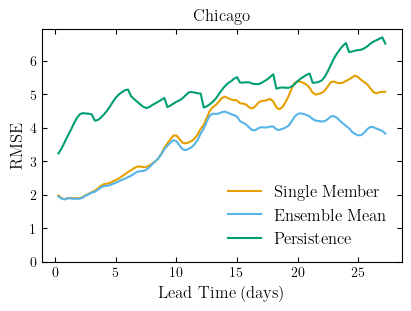

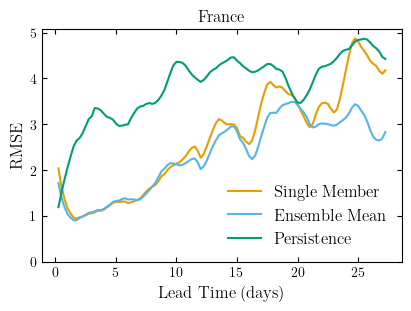

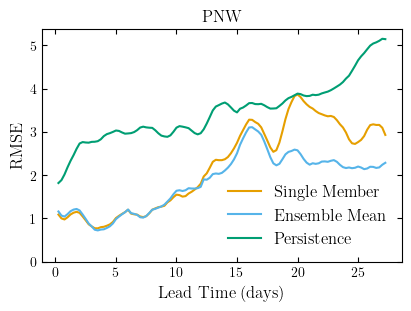

In [ ]:
AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT.nc")
Chicago3 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_Chicago3.nc")
A1 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_A1.nc")
region_idx = list(AT.region.values).index('Chicago')
T_idx = list(AT.T.values).index(3)

for var in Chicago3.data_vars:
    AT[var].loc[dict(region='Chicago', T=3)] = Chicago3[var].sel(region='Chicago', T=3)

# missing_T = np.setdiff1d(A1.T.values, AT.T.values)
# if len(missing_T) > 0:
#     new_T = np.sort(np.concatenate([AT.T.values, missing_T]))
#     AT = AT.reindex(T=new_T)
# for var in A1.data_vars:
#     AT[var].loc[dict(T=A1.T.values)] = A1[var]

# Step 1: Subset A1 to AT's prediction_timedelta values
A1 = A1.sel(prediction_timedelta=AT.prediction_timedelta)

# Step 2: Extend AT.T if needed
missing_T = np.setdiff1d(A1.T.values, AT.T.values)
if len(missing_T) > 0:
    AT = AT.reindex(T=np.sort(np.concatenate([AT.T.values, missing_T])))

# Step 3: Assign each variable
for var in A1.data_vars:
    AT[var].loc[dict(T=A1.T.values)] = A1[var]

# Define a color-blind-friendly palette (e.g., Okabe-Ito)
forecast_styles = {
    'single': {'color': '#E69F00', 'label': 'Single Member'},    # orange
    'mean': {'color': '#56B4E9', 'label': 'Ensemble Mean'},      # blue
    'persist': {'color': '#009E73', 'label': 'Persistence'}      # green
}

T_linestyles = {
    1: '-',
    3: '-',
    5: '-',
    7: '-'
}

# Use only JJA
ds_jja = AT.sel(season='JJA')
regions = ds_jja.region.values
Ts = [1]
timedays = ds_jja.prediction_timedelta / np.timedelta64(1, 'D')

for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'rmse_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays, data.values.squeeze(),
                    label=style['label'],
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )

        ax.set_title(region)
        ax.set_xlabel(r'Lead Time (days)')
        ax.set_ylabel(r'RMSE')
        ax.set_ylim(bottom=0)
        ax.legend(frameon=False)

        plt.savefig(SAVE_DIR + f'rmse_{region}_{T}.' + savefig_format,
                    dpi=600, format=savefig_format, bbox_inches='tight')
        plt.show()

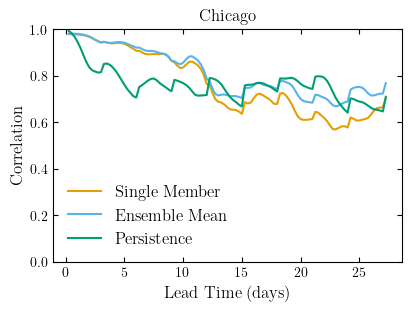

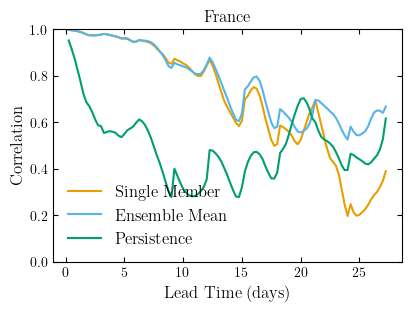

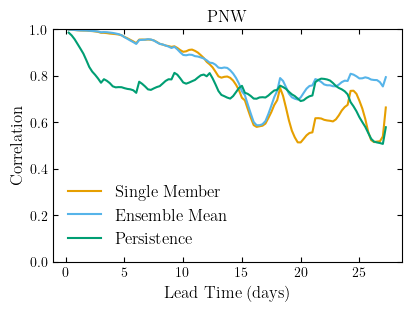

In [ ]:
for region in regions:
    fig, ax = plt.subplots(figsize=(4, 3), layout='compressed')
    fig.patch.set_facecolor('w')

    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'corr_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays, data.values.squeeze(),
                    label=style['label'],
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )

        ax.set_title(region)
        ax.set_xlabel(r'Lead Time (days)')
        ax.set_ylabel(r'Correlation')
        ax.set_ylim(0, 1)
        ax.legend(frameon=False)

        plt.savefig(SAVE_DIR + f'corr_{region}_{T}.' + savefig_format,
                    dpi=600, format=savefig_format, bbox_inches='tight')
        plt.show()

In [ ]:
AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT.nc")
AT

/glade/derecho/scratch/aasche/tmp/ipykernel_166952/3485385588.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT.nc")


<xarray.Dataset> Size: 56kB
Dimensions:               (season: 1, region: 3, T: 3, prediction_timedelta: 109)
Coordinates:
  * season                (season) <U3 12B 'JJA'
  * region                (region) <U7 84B 'Chicago' 'France' 'PNW'
  * T                     (T) int64 24B 3 5 7
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 872B 06:00:0...
Data variables:
    rmse_single           (season, region, T, prediction_timedelta) float64 8kB ...
    corr_single           (season, region, T, prediction_timedelta) float64 8kB ...
    rmse_mean             (season, region, T, prediction_timedelta) float64 8kB ...
    corr_mean             (season, region, T, prediction_timedelta) float64 8kB ...
    rmse_persist          (season, region, T, prediction_timedelta) float64 8kB ...
    corr_persist          (season, region, T, prediction_timedelta) float64 8kB ...
    crps_ens              (season, region, T, prediction_timedelta) float64 8kB ...

In [ ]:
Chicago3 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_Chicago3.nc")
Chicago3

/glade/derecho/scratch/aasche/tmp/ipykernel_166952/1347726263.py:1: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  Chicago3 = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT_Chicago3.nc")


<xarray.Dataset> Size: 7kB
Dimensions:               (season: 1, region: 1, T: 1, prediction_timedelta: 109)
Coordinates:
  * season                (season) <U3 12B 'JJA'
  * region                (region) <U7 28B 'Chicago'
  * T                     (T) int64 8B 3
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 872B 06:00:0...
Data variables:
    rmse_single           (season, region, T, prediction_timedelta) float64 872B ...
    corr_single           (season, region, T, prediction_timedelta) float64 872B ...
    rmse_mean             (season, region, T, prediction_timedelta) float64 872B ...
    corr_mean             (season, region, T, prediction_timedelta) float64 872B ...
    rmse_persist          (season, region, T, prediction_timedelta) float64 872B ...
    corr_persist          (season, region, T, prediction_timedelta) float64 872B ...
    crps_ens              (season, region, T, prediction_timedelta) float64 872B ...

In [ ]:
region_idx = list(AT.region.values).index('Chicago')
T_idx = list(AT.T.values).index(3)

for var in Chicago3.data_vars:
    AT[var].loc[dict(region='Chicago', T=3)] = Chicago3[var].sel(region='Chicago', T=3)

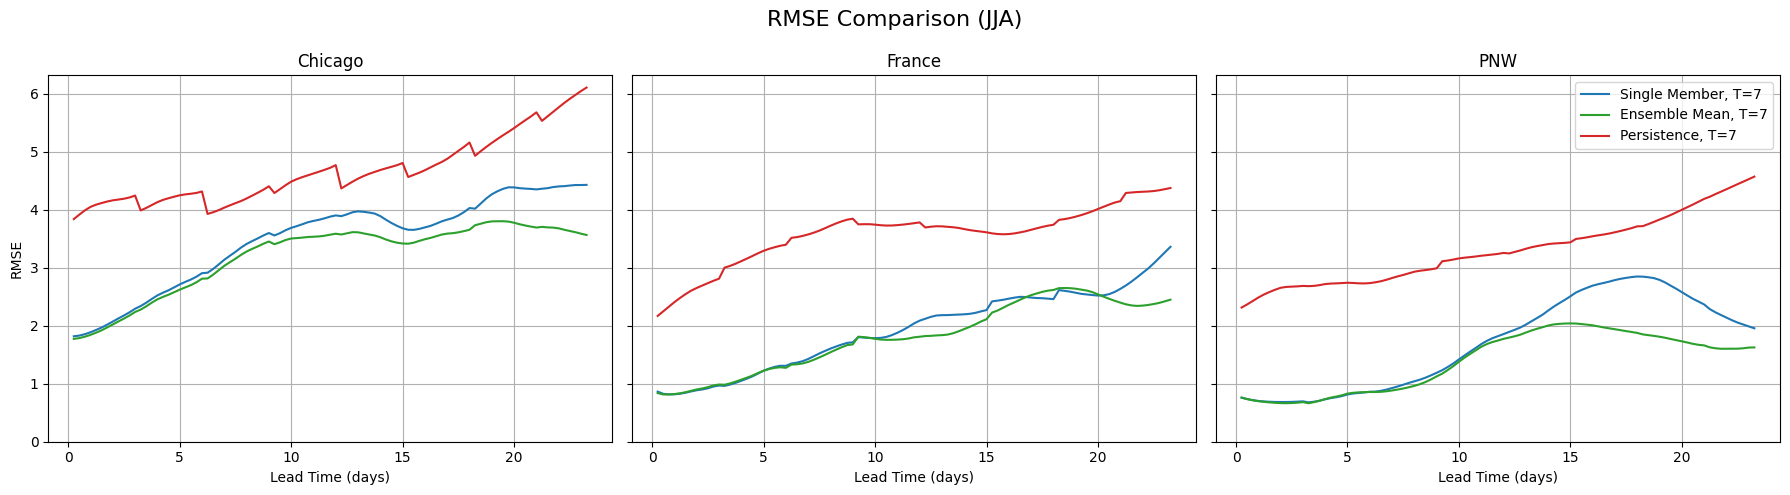

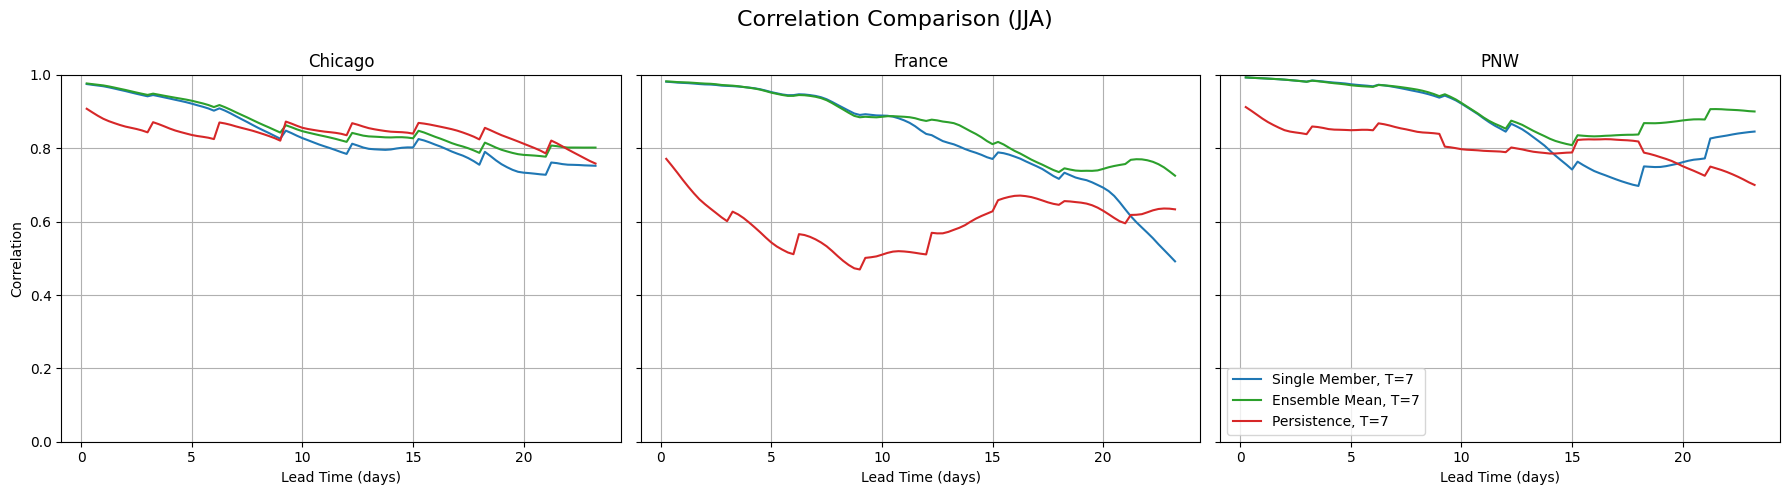

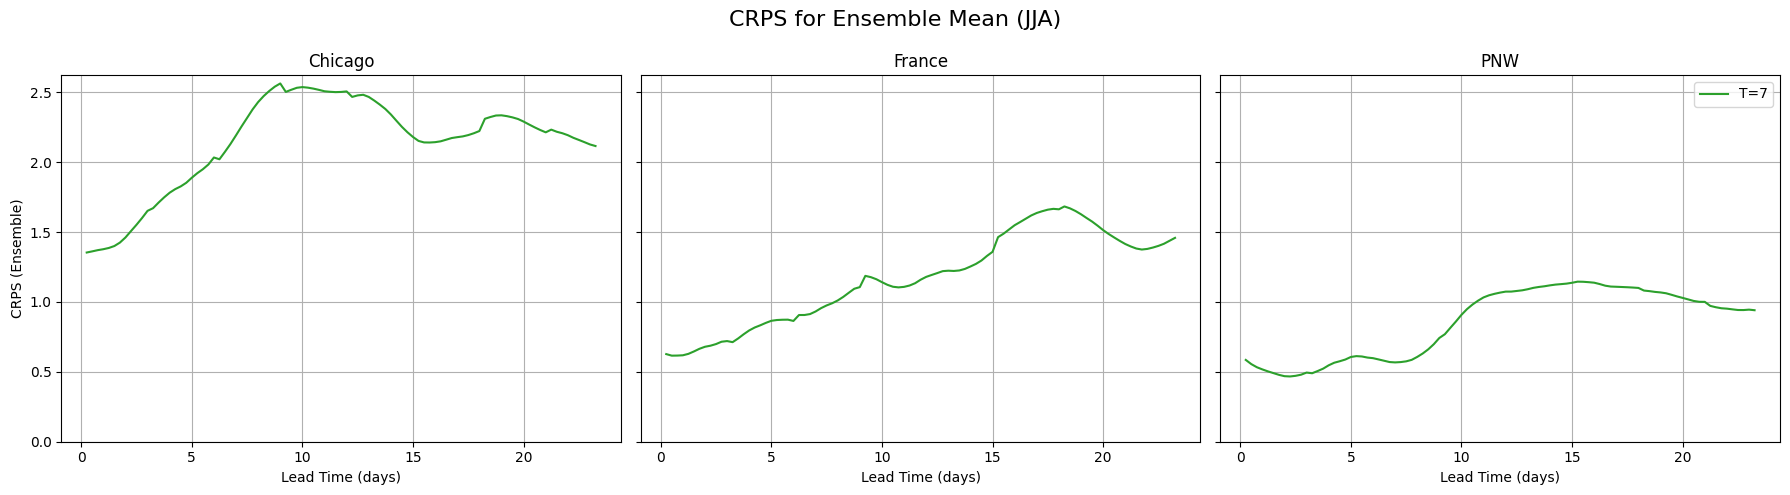

In [30]:
# AT = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/JJA_AT.nc")

# Use only JJA season
ds_jja = AT.sel(season='JJA')

# Forecast types and styling
forecast_styles = {
    'single': {'color': 'tab:blue', 'label': 'Single Member'},
    'mean': {'color': 'tab:green', 'label': 'Ensemble Mean'},
    'persist': {'color': 'tab:red', 'label': 'Persistence'}
}

T_linestyles = {
    3: ':',
    5: '--',
    7: '-'
}

regions = ds_jja.region.values
# Ts = ds_jja.T.values
Ts = [7]
timedays = ds_jja.prediction_timedelta / np.timedelta64(1, 'D')  # in days

### ---------- 1. RMSE ----------
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'rmse_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays,
                    data.values.squeeze(),
                    label=f"{style['label']}, T={T}",
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )
    ax.set_title(region)
    ax.set_xlabel('Lead Time (days)')
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.set_ylabel('RMSE')
    ax.grid(True)
    if i == 2:  # only add legend once
        ax.legend(loc='upper right')

fig.suptitle('RMSE Comparison (JJA)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

### ---------- 2. Correlation ----------
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    for T in Ts:
        for ftype, style in forecast_styles.items():
            var_name = f'corr_{ftype}'
            if var_name in ds_jja:
                data = ds_jja[var_name].sel(region=region, T=T)
                ax.plot(
                    timedays,
                    data.values.squeeze(),
                    label=f"{style['label']}, T={T}",
                    color=style['color'],
                    linestyle=T_linestyles[T]
                )
    ax.set_title(region)
    ax.set_xlabel('Lead Time (days)')
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel('Correlation')
    ax.grid(True)
    if i == 2:
        ax.legend(loc='lower left')

fig.suptitle('Correlation Comparison (JJA)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

### ---------- 3. CRPS (only Ensemble Mean) ----------
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    for T in Ts:
        data = ds_jja['crps_ens'].sel(region=region, T=T)
        ax.plot(
            timedays,
            data.values.squeeze(),
            label=f'T={T}',
            linestyle=T_linestyles[T],
            color='tab:green'
        )
    ax.set_title(region)
    ax.set_xlabel('Lead Time (days)')
    ax.set_ylim(bottom=0)
    if i == 0:
        ax.set_ylabel('CRPS (Ensemble)')
    ax.grid(True)
    if i == 2:
        ax.legend(loc='upper right')

fig.suptitle('CRPS for Ensemble Mean (JJA)', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2538621278.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2538621278.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2538621278.py:12: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
/glade/derech

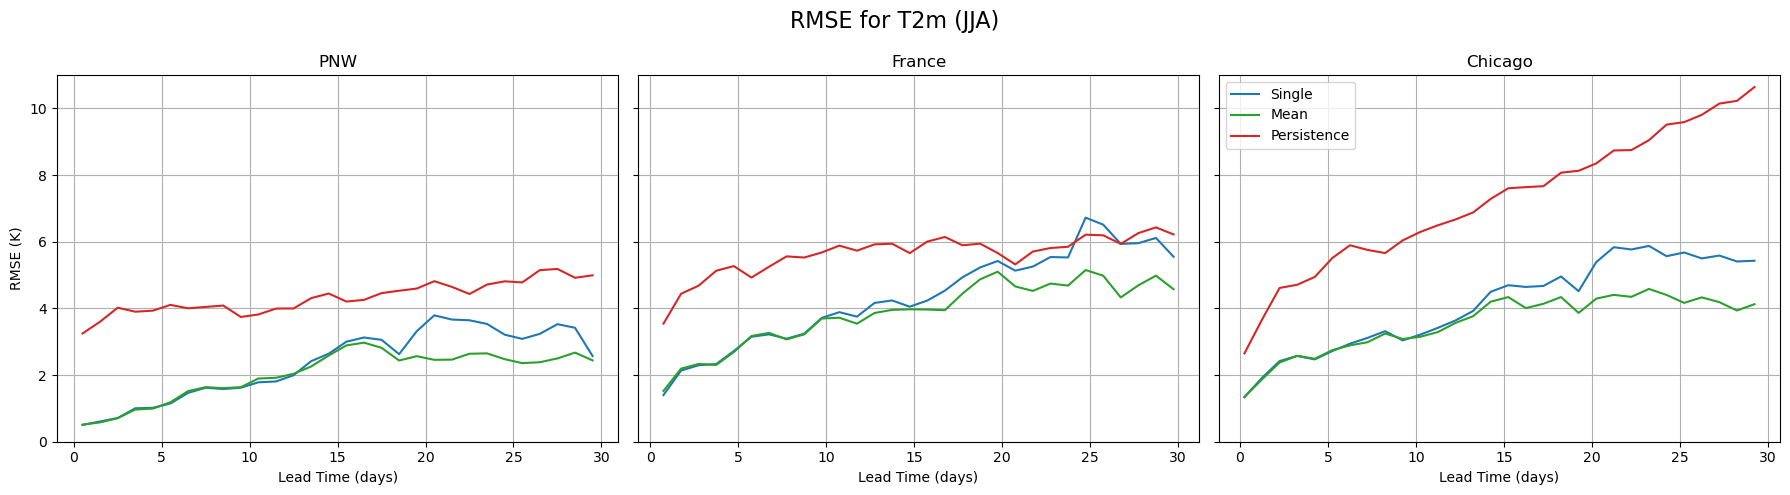

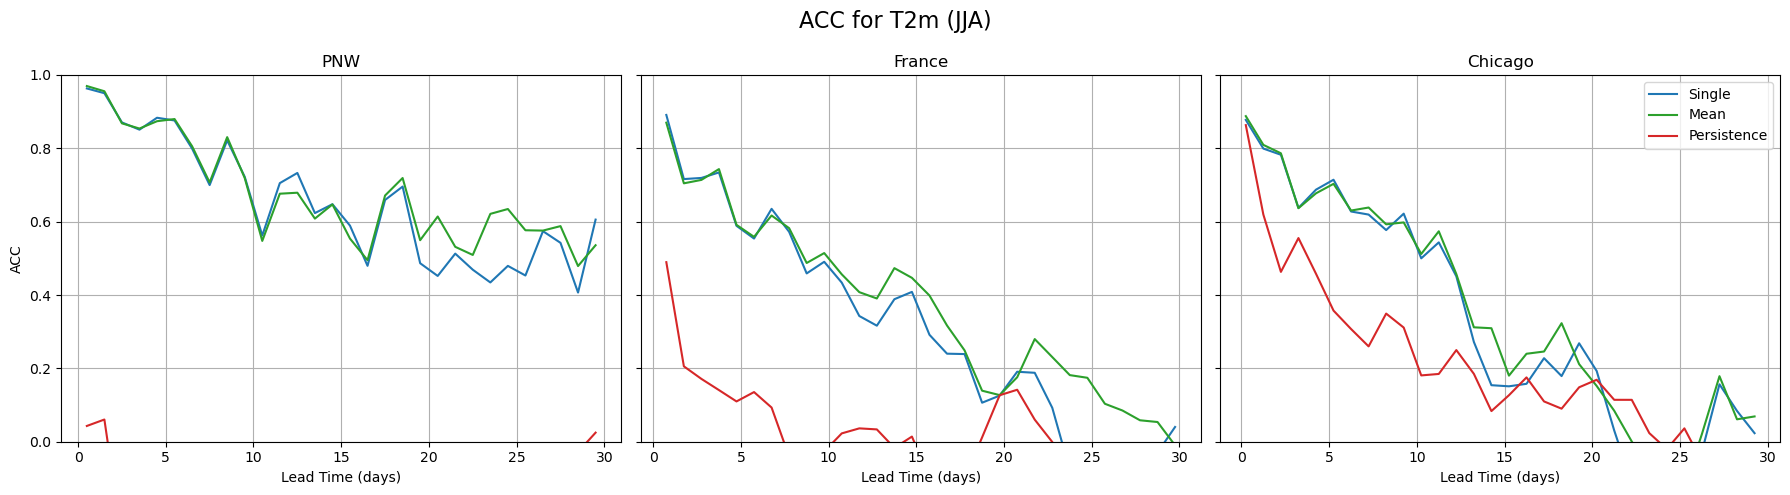

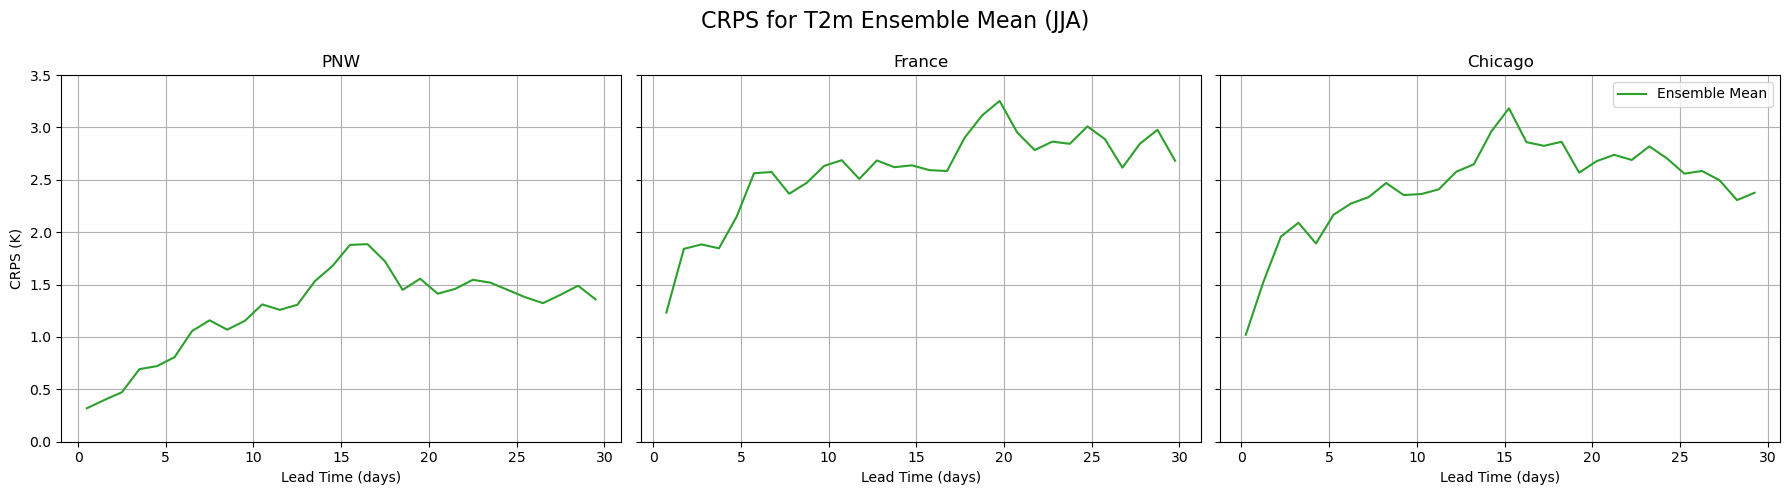

In [10]:
# -----------------------------
# Settings
methods = ['single', 'mean', 'persistence']
regions = ['PNW', 'France', 'Chicago']
method_colors = {'single': 'tab:blue', 'mean': 'tab:green', 'persistence': 'tab:red'}
var_name = 'tas'
metric_dim = 'metric'

# -----------------------------
# Load Data
det_files = {m: f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{m}_JJA_tas_deterministic.nc" for m in methods}
det_ds = {m: xr.open_dataset(det_files[m]) for m in methods}
crps_ds = xr.open_dataset("/glade/derecho/scratch/aasche/PLASIM/results/paper/mean_JJA_tas_CRPS.nc")

# -----------------------------
# Helper Functions

def select_leads_by_offset(ds, offset):
    lead_times = pd.to_timedelta(ds['lead_time'].values)
    mask = (lead_times % np.timedelta64(1, 'D')) == offset
    return ds.isel(lead_time=np.where(mask)[0])

def lead_time_days(ds):
    return pd.to_timedelta(ds.lead_time.values) / np.timedelta64(1, 'D')

# -----------------------------
# Get best offset per region
best_offsets = {
    "PNW": np.timedelta64(int(0.5 * 24 * 60 * 60), 's'),      # 12h
    "France": np.timedelta64(int(0.75 * 24 * 60 * 60), 's'),  # 18h
    "Chicago": np.timedelta64(int(0.25 * 24 * 60 * 60), 's')  # 6h
}

# -----------------------------
# RMSE Plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    offset = best_offsets[region]
    for method in methods:
        ds_subset = select_leads_by_offset(det_ds[method], offset)
        mse = ds_subset[var_name].sel(metric='MSE', region=region)
        rmse = np.sqrt(mse)
        ax.plot(
            lead_time_days(ds_subset),
            rmse,
            label=method.capitalize(),
            color=method_colors[method]
        )
    ax.set_title(region)
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylim(0,11)
    if i == 0:
        ax.set_ylabel("RMSE (K)")
    if i == 2:
        ax.legend()
    ax.grid(True)

fig.suptitle("RMSE for T2m (JJA)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# -----------------------------
# ACC Plot
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    offset = best_offsets[region]
    for method in methods:
        ds_subset = select_leads_by_offset(det_ds[method], offset)
        acc = ds_subset[var_name].sel(metric='ACC', region=region)
        ax.plot(
            lead_time_days(ds_subset),
            acc,
            label=method.capitalize(),
            color=method_colors[method]
        )
    ax.set_title(region)
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylim(0, 1)
    if i == 0:
        ax.set_ylabel("ACC")
    if i == 2:
        ax.legend()
    ax.grid(True)

fig.suptitle("ACC for T2m (JJA)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

# -----------------------------
# CRPS Plot (Ensemble Mean only)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for i, region in enumerate(regions):
    ax = axs[i]
    offset = best_offsets[region]
    crps_subset = select_leads_by_offset(crps_ds, offset)
    crps = crps_subset[var_name].sel(metric='CRPS', region=region)
    ax.plot(
        lead_time_days(crps_subset),
        crps,
        label='Ensemble Mean',
        color=method_colors['mean']
    )
    ax.set_title(region)
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylim(0,3.5)
    if i == 0:
        ax.set_ylabel("CRPS (K)")
    if i == 2:
        ax.legend()
    ax.grid(True)

fig.suptitle("CRPS for T2m Ensemble Mean (JJA)", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:18: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, 

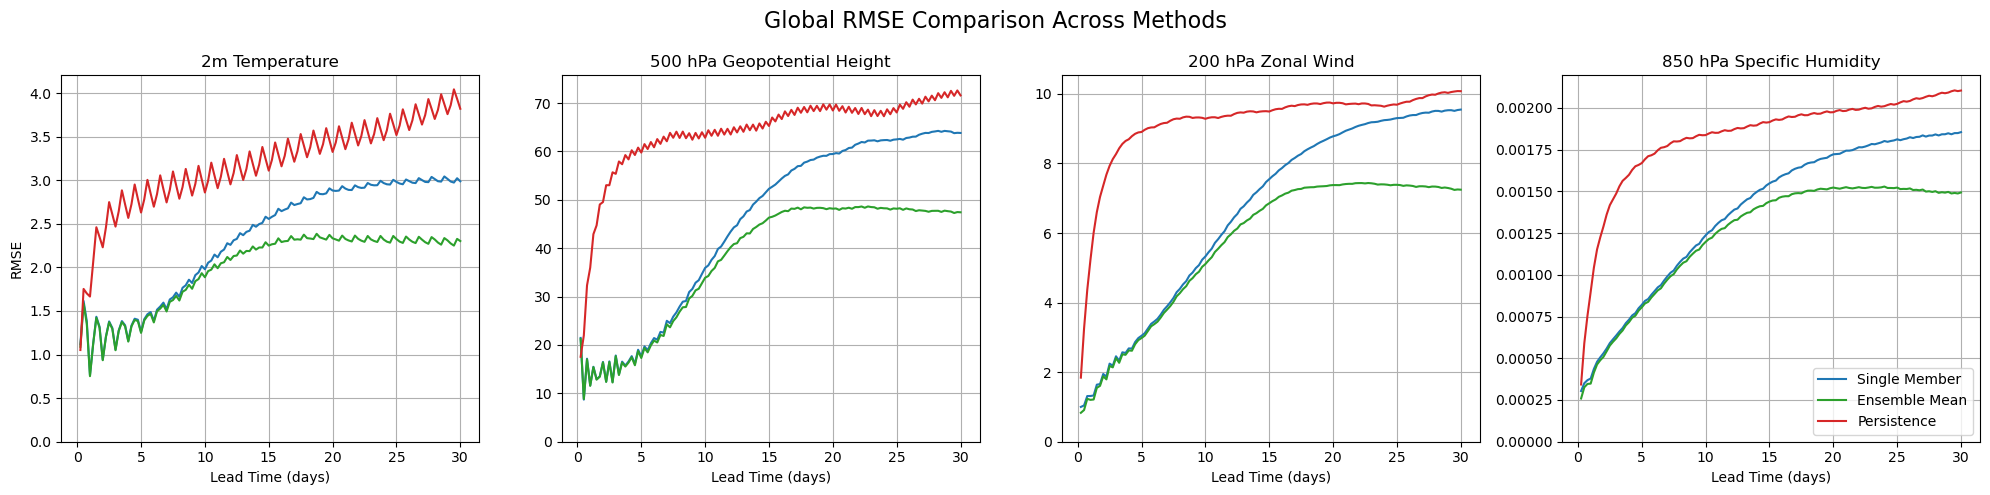

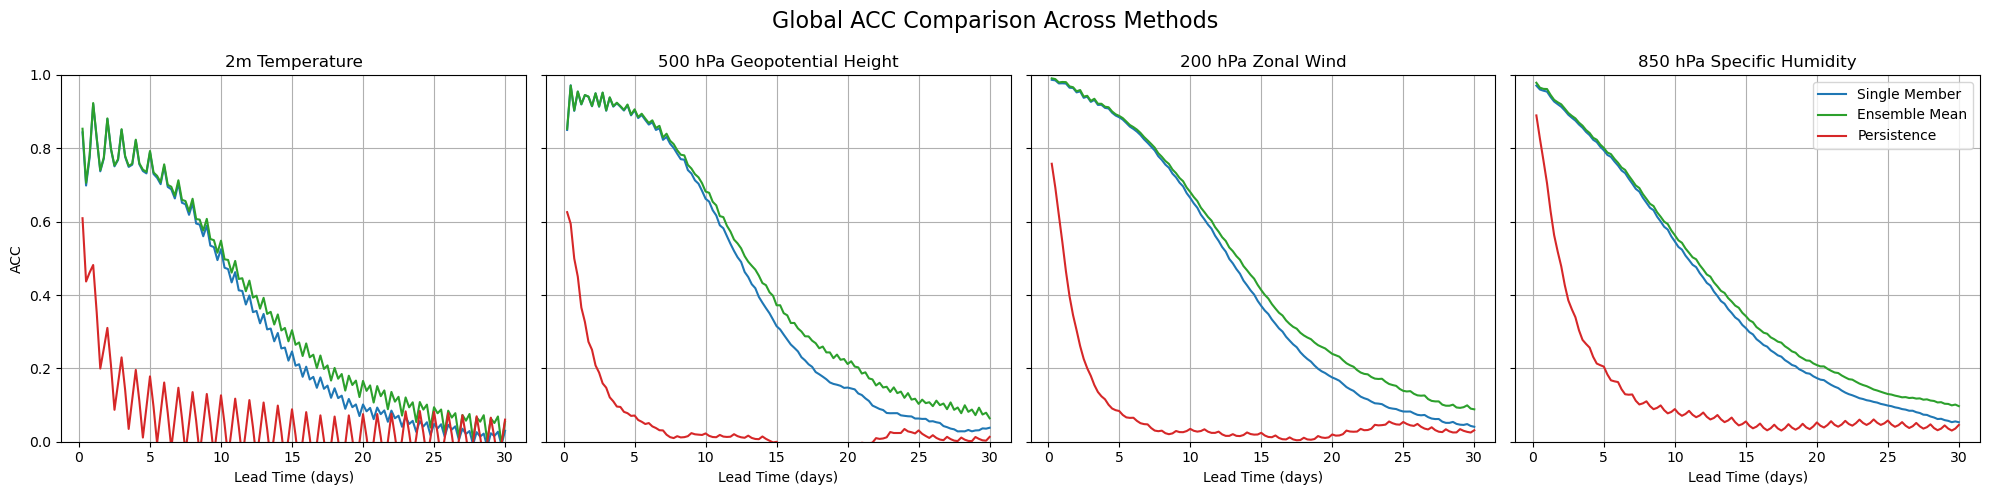

/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:72: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_crps = xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/global_{var}_crps.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:72: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_crps = xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/global_{var}_crps.nc")
/glade/derecho/scratch/aasche/tmp/ipykernel_90951/2887576311.py:72: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' inst

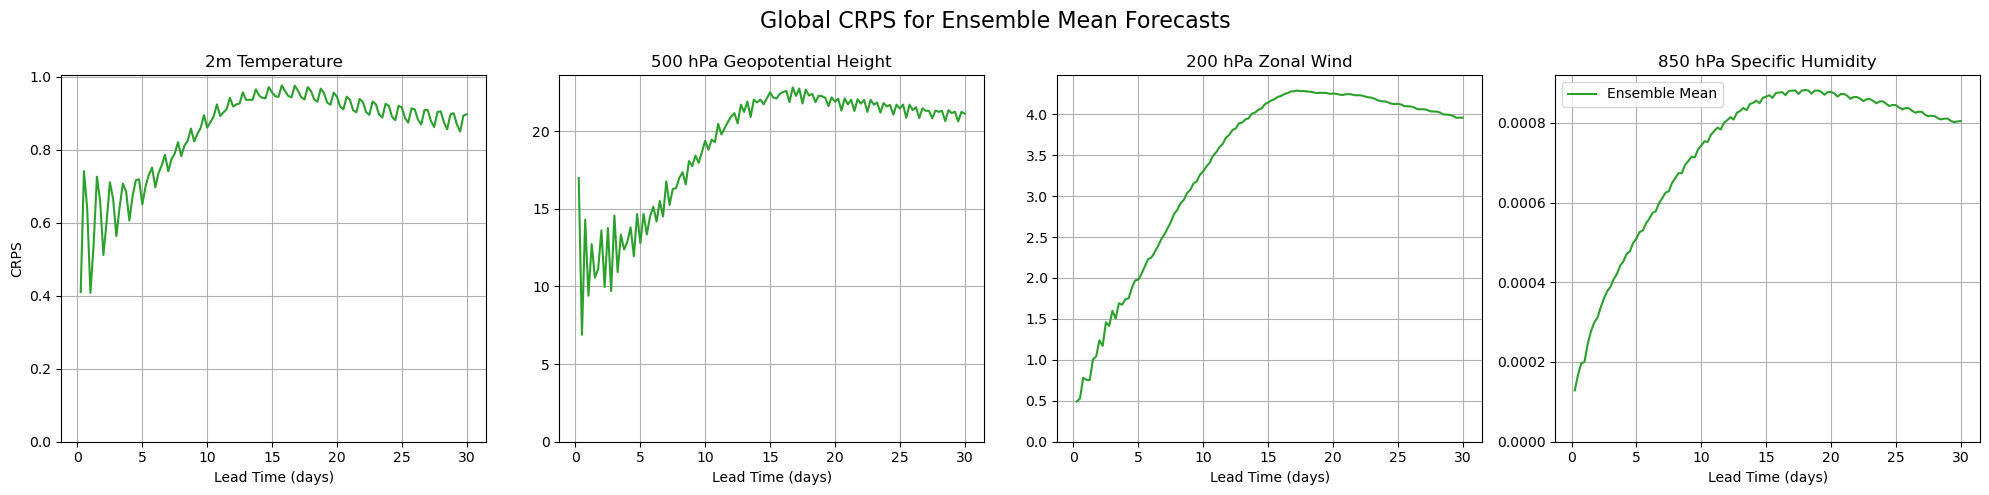

In [16]:
# -------------------
# Variable configuration
var_configs = {
    'tas': {'name': '2m Temperature', 'level': None},
    'zg':  {'name': '500 hPa Geopotential Height', 'level': 50000},
    'ua':  {'name': '200 hPa Zonal Wind', 'level': 20000},
    'hus': {'name': '850 hPa Specific Humidity', 'level': 85000}
}

# Prediction methods
methods = ['single', 'mean', 'persistence']
method_labels = {'single': 'Single Member', 'mean': 'Ensemble Mean', 'persistence': 'Persistence'}
method_colors = {'single': 'tab:blue', 'mean': 'tab:green', 'persistence': 'tab:red'}

# -------------------
# Load deterministic datasets
det_datasets = {
    method: xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/{method}_global_ACC_tas_zg_ua_hus.nc")
    for method in methods
}

# -------------------
# Plot RMSE and ACC
for metric in ['RMSE', 'ACC']:
    fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharey=(metric == 'ACC'))
    for i, (var, cfg) in enumerate(var_configs.items()):
        ax = axs[i]
        for method in methods:
            ds = det_datasets[method]
            data = ds[var]
            lead_days = pd.to_timedelta(ds['lead_time'].values) / np.timedelta64(1, 'D')

            # Select appropriate slice
            if cfg['level'] is None:
                metric_data = data.sel(metric='MSE' if metric == 'RMSE' else 'ACC').squeeze()
            else:
                metric_data = data.sel(metric='MSE' if metric == 'RMSE' else 'ACC', level=cfg['level']).squeeze()

            if metric == 'RMSE':
                metric_data = np.sqrt(metric_data)

            ax.plot(
                lead_days,
                metric_data,
                label=method_labels[method],
                color=method_colors[method]
            )

        ax.set_title(cfg['name'])
        ax.set_xlabel("Lead Time (days)")
        ax.grid(True)
        if i == 0:
            ax.set_ylabel(metric)
        if i == 3:
            ax.legend()
        if metric == 'ACC':
            ax.set_ylim(0, 1)
        else:
            ax.set_ylim(bottom=0)

    fig.suptitle(f"Global {metric} Comparison Across Methods", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

# -------------------
# Plot CRPS (only available for mean method)
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for i, (var, cfg) in enumerate(var_configs.items()):
    ax = axs[i]
    try:
        ds_crps = xr.open_dataset(f"/glade/derecho/scratch/aasche/PLASIM/results/paper/global_{var}_crps.nc")
    except FileNotFoundError:
        print(f"Missing file: global_{var}_crps.nc — skipping")
        continue

    if cfg['level'] is not None:
        crps = ds_crps[var].sel(metric='CRPS', level=cfg['level']).squeeze()
    else:
        crps = ds_crps[var].sel(metric='CRPS').squeeze()

    lead_days = pd.to_timedelta(ds_crps['lead_time'].values) / np.timedelta64(1, 'D')

    ax.plot(
        lead_days,
        crps,
        label='Ensemble Mean',
        color=method_colors['mean']
    )
    ax.set_title(cfg['name'])
    ax.set_xlabel("Lead Time (days)")
    ax.set_ylim(bottom=0)
    ax.grid(True)
    if i == 0:
        ax.set_ylabel("CRPS")
    if i == 3:
        ax.legend()

fig.suptitle("Global CRPS for Ensemble Mean Forecasts", fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()